In [1]:
!pip install scikit-learn
!pip install tensorflow



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical


In [3]:
print("Downloading LFW dataset...")
lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

X = lfw.images
y = lfw.target

print("Dataset Downloaded Successfully!")
print("Total Images:", X.shape[0])
print("Image Shape:", X.shape[1:])


Dataset Downloaded Successfully!
Total Images: 1560
Image Shape: (50, 37)


(np.float64(-0.5), np.float64(36.5), np.float64(49.5), np.float64(-0.5))

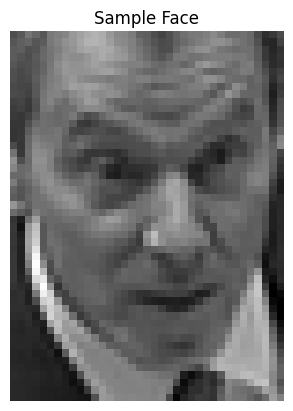

In [4]:
plt.imshow(X[0], cmap='gray')
plt.title("Sample Face")
plt.axis('off')


In [5]:
X = X / 255.0


In [6]:
num_classes = len(np.unique(y))
y = to_categorical(y, num_classes)

print("Number of People (Classes):", num_classes)


Number of People (Classes): 12


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Images:", X_train.shape[0])
print("Testing Images:", X_test.shape[0])


Training Images: 1248
Testing Images: 312


In [8]:
model = Sequential()

model.add(Flatten(input_shape=X.shape[1:]))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
print("Training Started...")
model.fit(X_train, y_train, epochs=10)


Training Started...
Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2974 - loss: 2.4037
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3357 - loss: 2.1450
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3404 - loss: 2.1153
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3245 - loss: 2.1454
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3241 - loss: 2.1517
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3358 - loss: 2.1234
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3368 - loss: 2.1210
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3346 - loss: 2.1280
Epoch 9/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3654 - loss: 2.0769
Epoch 10/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3219 - loss: 2.1383


In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3436 - loss: 2.0579  
Test Accuracy: 0.34294870495796204
